In [1]:
import sys
sys.path.append('..')
import phd_ms
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

In [2]:

#Change this line to the directory where inputs are stored
#Omit .h5ad extension!

IN_DIR = '/home/pbeamer/Documents/h5ad/scanit/'

DATASET = 'adata_151673'
emb = 'X_scanit'
INPUT_FILE= IN_DIR+DATASET+'_scanit'

#Set the scale parameters we want to use, and keys to save
RESOLUTIONS = np.linspace(start=0.15,stop=.95,num=8)
RES_KEYS = ['leiden_'+str(r) for r in RESOLUTIONS]
GROUND_TRUTH = 'cluster'


In [3]:

#Run clusterings for each resolution and save
'''
Preprocess leiden clusterings for given dataset

Arguments: 
input_file: path to the input file
output_file: is the path where the output will be saved
embedding: anndata field of the embedding to use
resolutions: Resolution parameters
keys = Keys to save clusters in adata.obs
ground_truth: The ground truth field in adata.obs

Output: adata with clusters in adata.obs[keys[i]] for each resolution i
'''
phd_ms.tl.preprocess_leiden(INPUT_FILE,output_file=INPUT_FILE,emb=emb,resolution=RESOLUTIONS,
                            res_keys=RES_KEYS,ground_truth=GROUND_TRUTH,neighbors=5)

#read the adata file
adata = sc.read_h5ad(INPUT_FILE+'.h5ad')


<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

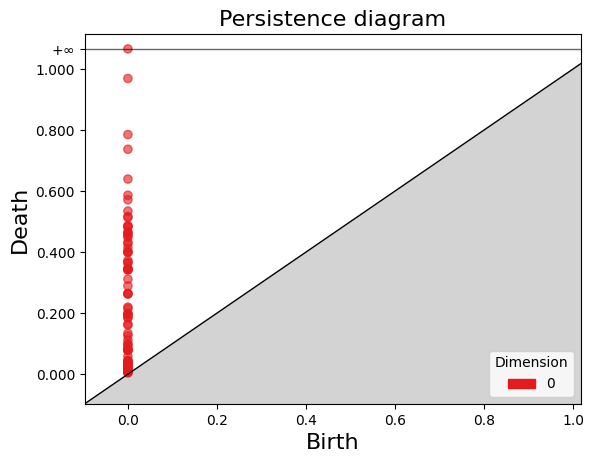

In [4]:
'''
Build cluster filtration

Arguments: 
input_file: path to the input file
output_file: is the path where the output will be saved
embedding: anndata field of the embedding to use
resolutions: Resolution parameters
keys = Keys to save clusters in adata.obs
ground_truth: The ground truth field in adata.obs

Output: adata with clusters in adata.obs[keys[i]] for each resolution i
'''
cluster_complex,clusterings= phd_ms.tl.cluster_filtration(adata,res_keys=RES_KEYS,index='containment',order=range(len(RES_KEYS)),)
from gudhi import plot_persistence_diagram
from gudhi import SimplexTree
plot_persistence_diagram(cluster_complex.persistence(),legend=True)

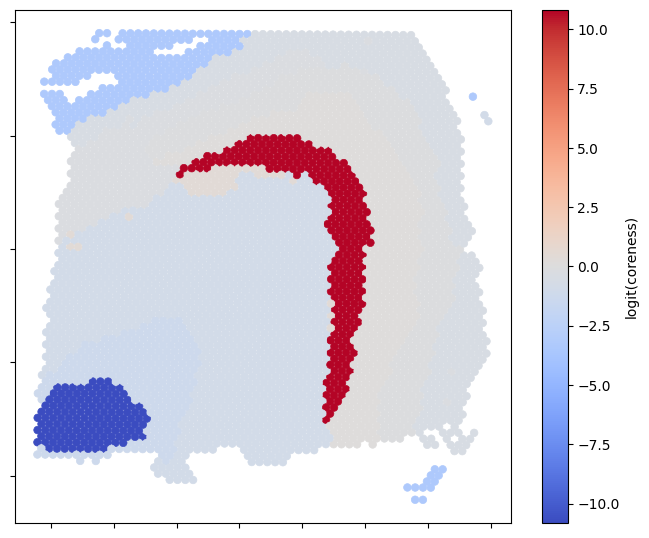

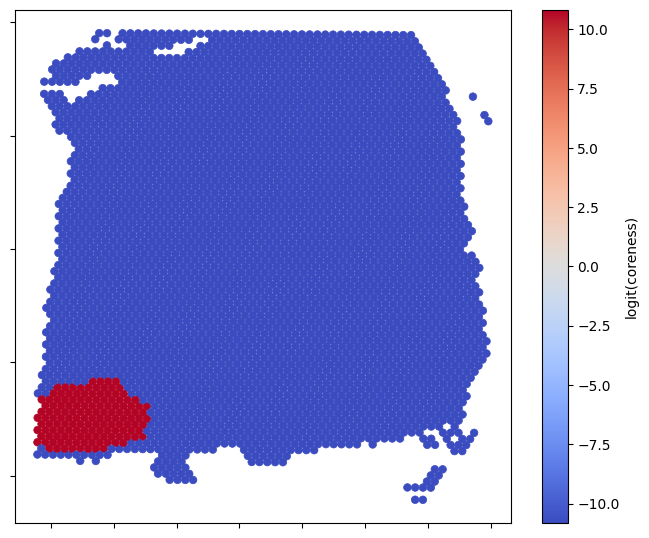

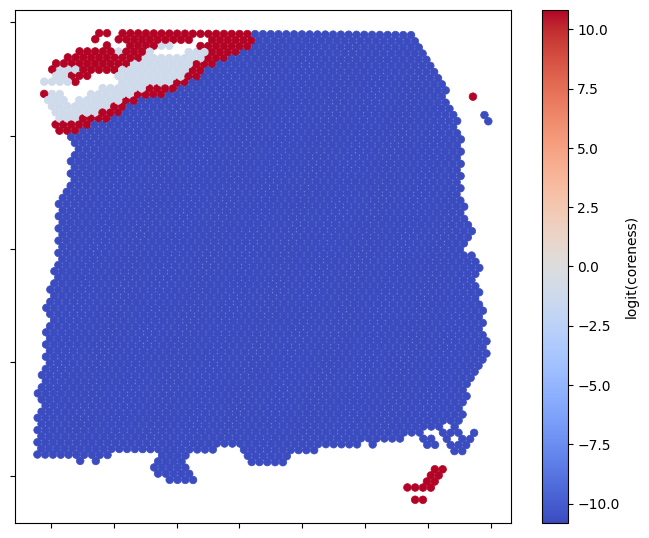

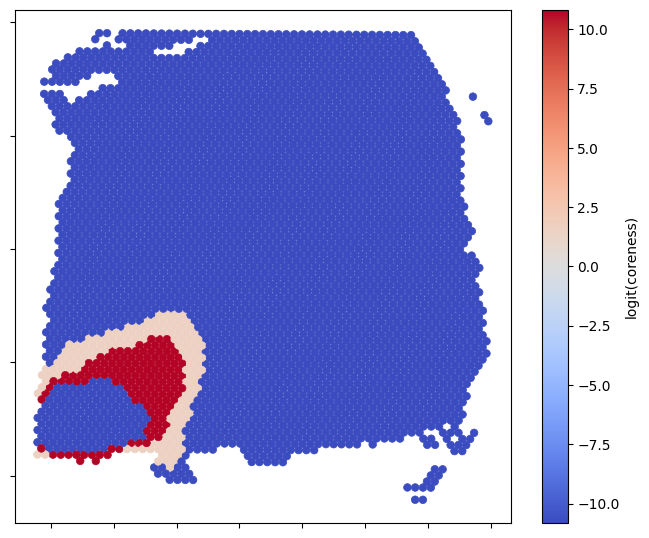

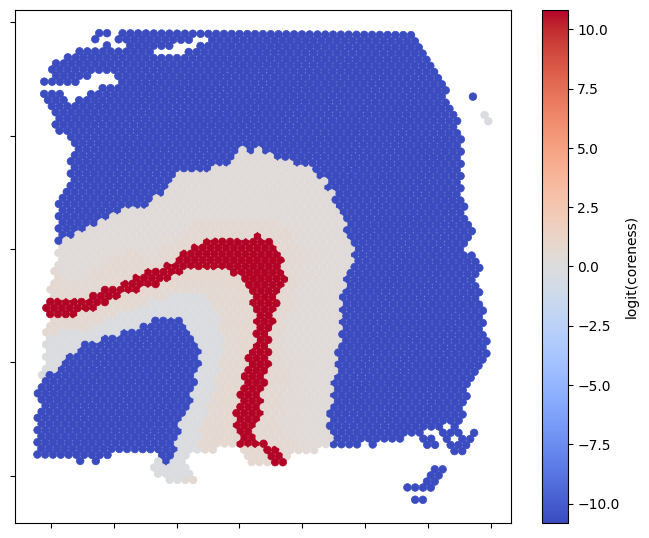

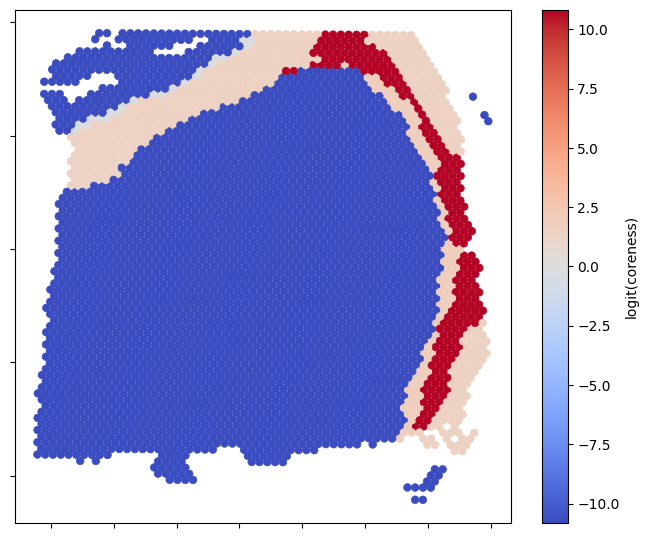

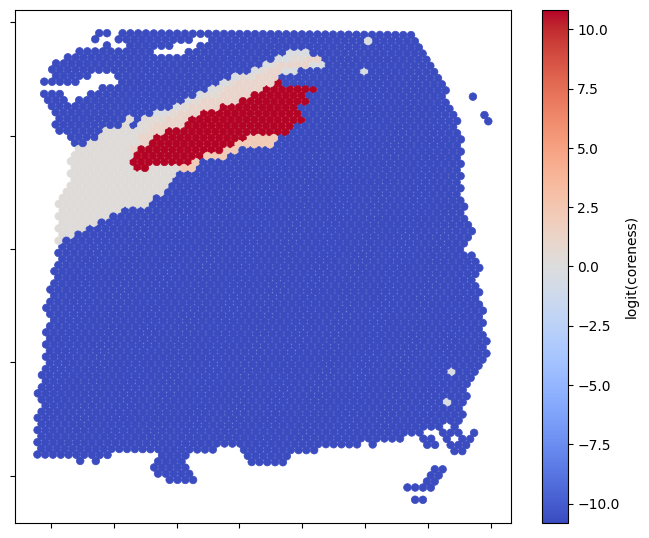

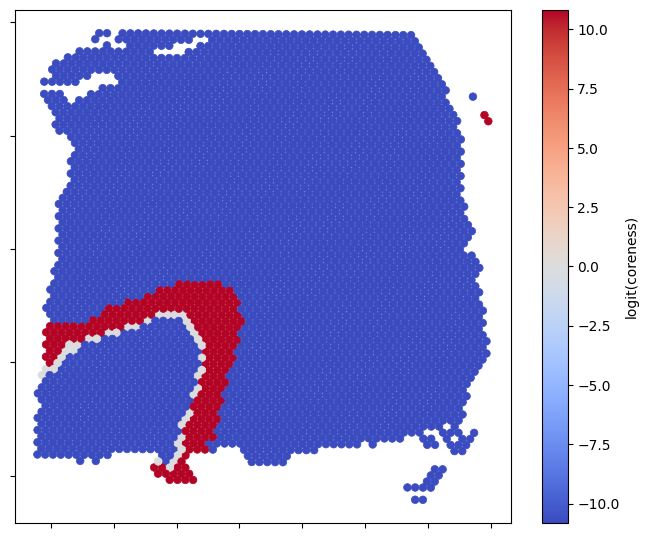

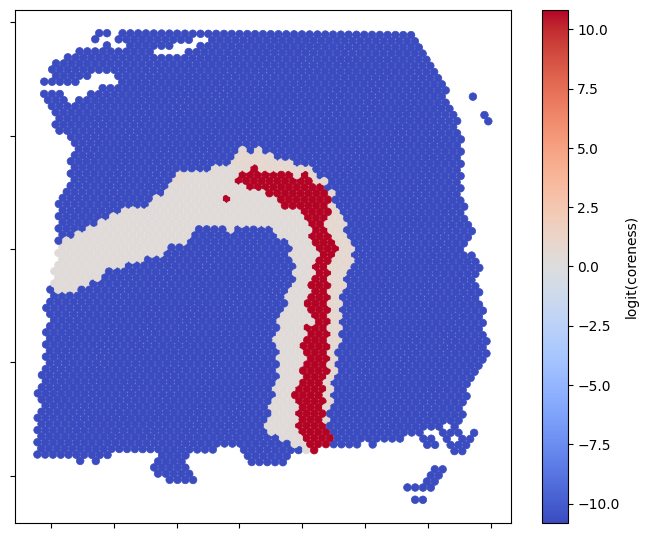

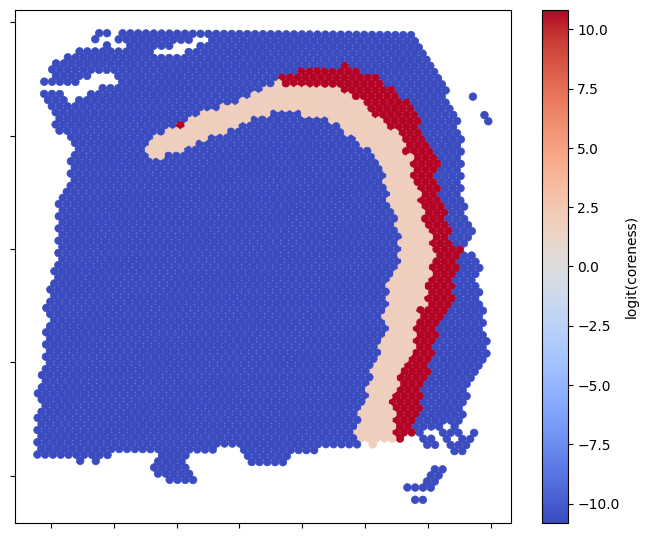

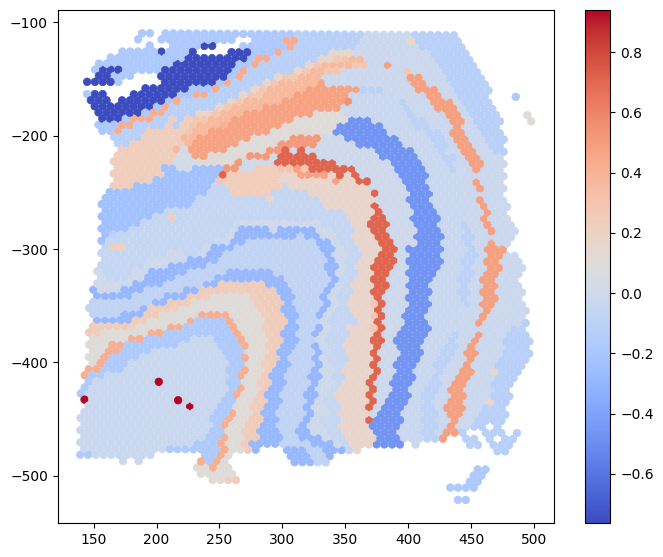

In [5]:

'''
Generate and map multiscale domains

Arguments:
spatial: spatial coordinates of points
cluster_complex: gudhi simplex tree of cluster filtration
clusterings: list of clusters at each resolution, containing cell indices
num_domains: number of multiscale domains to map, if 0 then all domains
filt: filter out persistent clusters with persistence less than this value
order: order of the output,'size' or default 'persistence'
redundant_filter: filter out domains which are to similar to previously examined domains, default is False
plots: 'on' to plot the domains

Output:
list of multiscale domains, consisting of coreness score for each point
'''
phd_ms.tl.map_multiscale(adata.obsm['spatial'],cluster_complex,clusterings,num_domains=10,order='persistence',plots='on');


0.5711289694343314


100%|██████████| 100000/100000 [02:15<00:00, 739.31it/s]


best score:0.6541263051176279
best coverage:0.9700913874273055
NMI: 0.6541263051176279, MI: 1.266035112290193


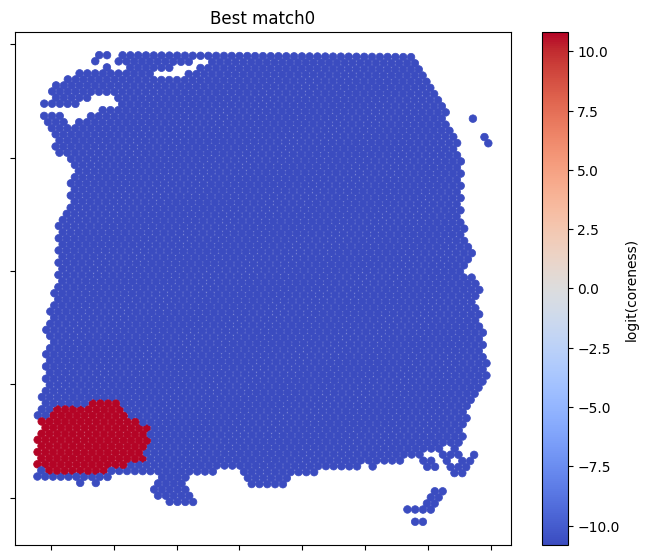

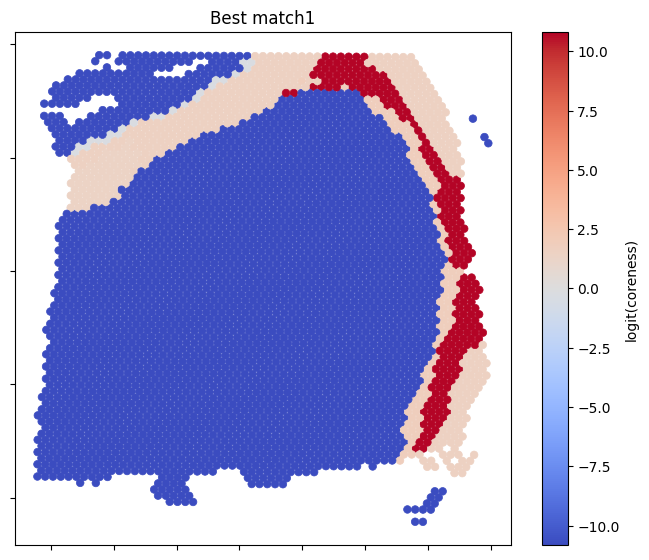

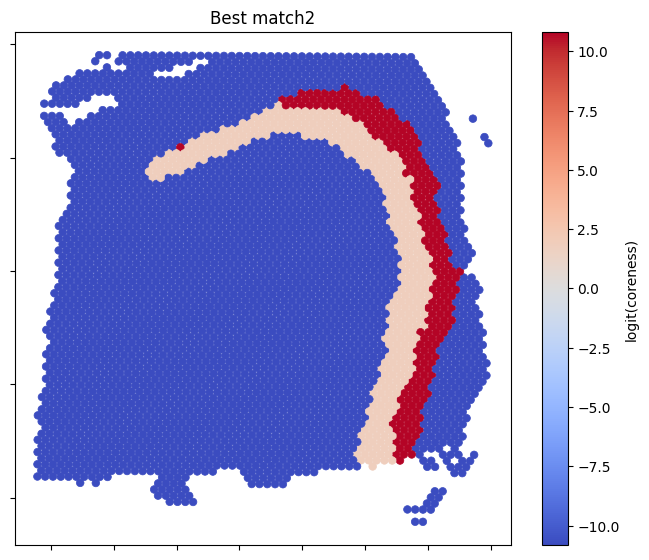

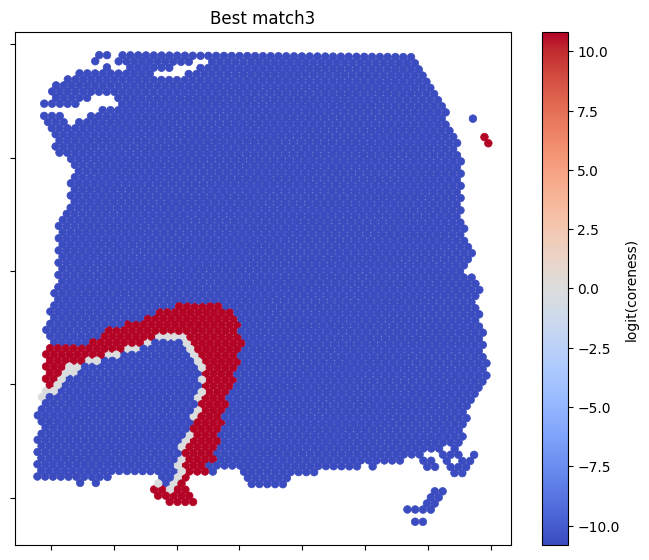

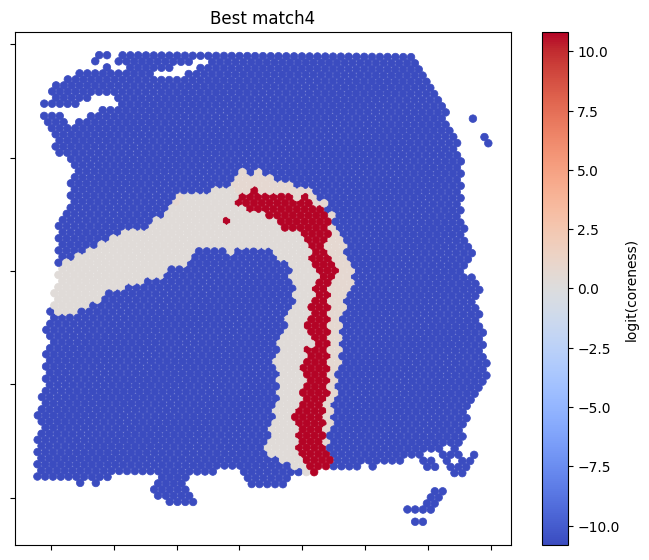

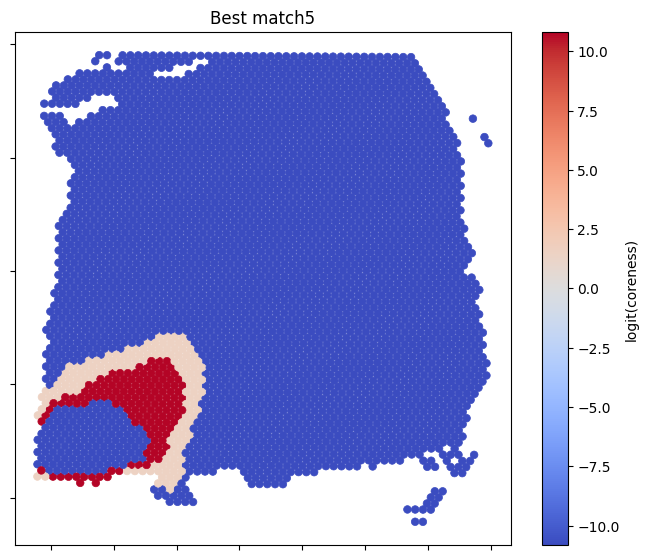

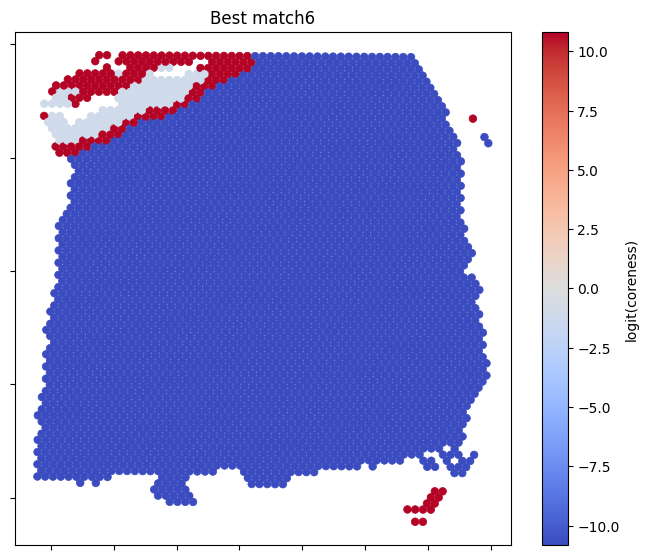

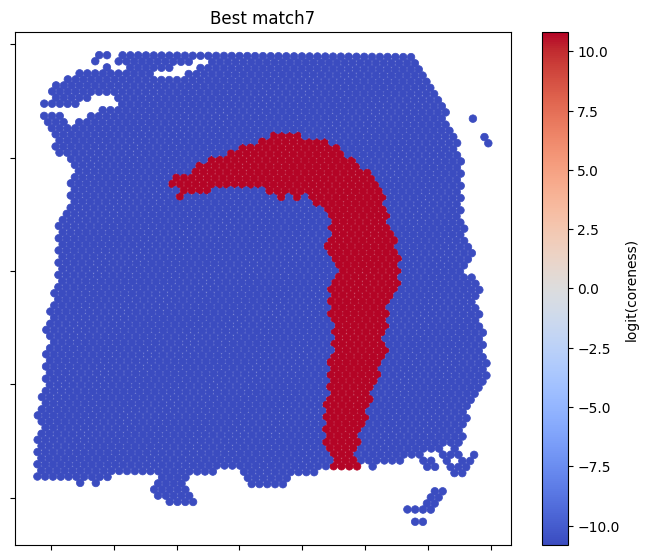

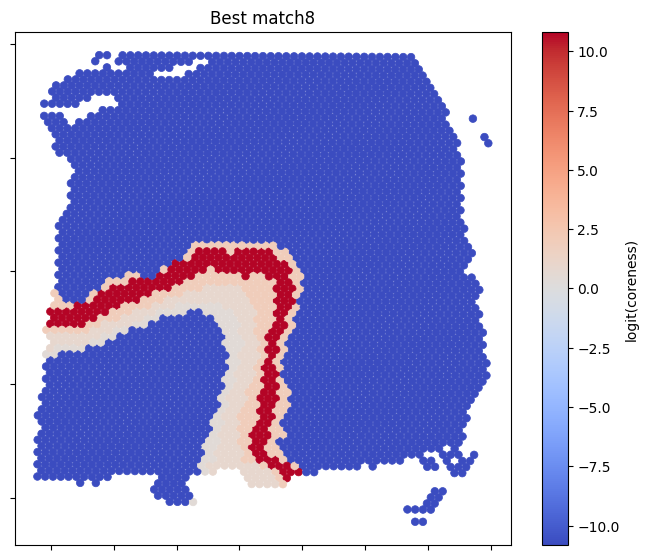

{'nmi': np.float64(0.6541263051176279), 'nmi matches': [np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(8), np.int64(3), np.int64(2), np.int64(131), np.int64(17)], 'mi': np.float64(1.266035112290193)}


In [6]:
'''
Compute wasserstein distance between ground truth and multiscale domains

Arguments:
ground truth: ground_truth clustering
multiscale: matrix of coreness scores for each multiscale domain
spatial: spatial coordinates
plots: whether to plot matching ground truth and multiscale domains
conversion_factor: a scaling factor to convert output to the desired units of distance

Output:
costs: wasserstein distances (units of distance)
m: maximum distance between spots (units of distance)
'''

adata.obsm['multiscale']= phd_ms.tl.map_multiscale(adata.obsm['spatial'],cluster_complex,clusterings,num_domains=0,filt=0,order='persistence',redundant_filter=False,plots='off')
m = phd_ms.tl.ground_truth_benchmark(adata.obs[GROUND_TRUTH],adata.obsm['multiscale'],adata.obsm['spatial'],plots=True,conversion_factor=16.435,metrics=['nmi'])
print(m)

In [7]:

#compare against single scale which best matches ground truth number of clusters
r = np.argmin(list(abs(len(adata.obs[GROUND_TRUTH].cat.categories.to_list()) - len(adata.obs[key].cat.categories.to_list())) for key in RES_KEYS))
single_scale = np.zeros((len(adata.obs[GROUND_TRUTH]),0))
for key in [RES_KEYS[r]]:
    clusters = adata.obs[key]
    ss = np.zeros((len(clusters),len(clusters.cat.categories.tolist())))
    for i in range(len(clusters)):
            if isinstance(clusters.iloc[i],float):
                continue
            index = next(j for j in range(len(clusters.cat.categories.tolist())) if clusters.cat.categories.tolist()[j] == clusters.iloc[i])
            ss[i,index] = 1
    single_scale = np.concatenate((single_scale,ss),axis=1)
#Pick the resolution which best matches the ground truth number of clusters
r = RES_KEYS[r]
#Convert to distribution
m = phd_ms.tl.ground_truth_benchmark(adata.obs[GROUND_TRUTH],adata.obs[r],adata.obsm['spatial'],plots=False,conversion_factor=16.435,metrics=['nmi'],single_scale=True)


NMI: 0.6472137671992403, MI: 1.2960835744366295


In [8]:
truth  = adata.obs[GROUND_TRUTH]
cluster = adata.obs[r]
l1 = np.zeros(len(truth))
l2 = np.zeros(len(truth))
for i in range(0,len(truth.cat.categories.tolist())):
            guy = list(n for n in range(0,len(truth)) if truth.iloc[n]==truth.cat.categories.tolist()[i])
            l1[guy] = i
for i in range(0,len(cluster.cat.categories.tolist())):
            guy = list(n for n in range(0,len(cluster)) if cluster.iloc[n]==cluster.cat.categories.tolist()[i])
            l2[guy] = i
from sklearn.metrics import adjusted_mutual_info_score
adjusted_mutual_info_score(l1,l2)

0.6446308908981107